# Notebook 4 — Modeling & Évaluation

---

## Pipeline

| Étape | Section | Ce qu'on fait |
|---|---|---|
| Imports | 1 | Charger `config.py` + librairies |
| Chargement | 2 | `df_train_final.csv` + `df_test_final.csv` + `selected_features.pkl` |
| Pipeline | 3 | `ImbPipeline` : SMOTE → StandardScaler → 3 modèles : LR → XGBoost → LightGBM + ImbPipeline |
| GridSearchCV | 4 | `scoring='recall'`, `cv=5` — 3 modèles |
| Évaluation seuil 0.5 | 5 | Recall, AUC, F1, Accuracy, Matrice de confusion |
| Seuil dynamique | 6 | Recherche OOF du seuil optimal |
| Comparaison finale | 7 | Tableau récap + Courbe ROC |
| Sauvegarde | 8 | `pipeline_final.pkl` |

---

**Prérequis** : `3_Feature_Engineering.ipynb` exécuté  
**Sorties** : `pipeline_final.pkl`

## 1. Imports & Configuration

In [2]:
%pip install xgboost       -q
%pip install lightgbm -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import sys
sys.path.insert(0, './src')
import importlib, config
importlib.reload(config)
from config import TARGET, RANDOM_STATE

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier

from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold,cross_val_predict
from sklearn.metrics         import (
    recall_score, precision_score, f1_score,
    roc_auc_score, accuracy_score,
    confusion_matrix, roc_curve, classification_report,average_precision_score
)
from imblearn.pipeline       import Pipeline as ImbPipeline
from imblearn.over_sampling  import SMOTE

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Chemins
OUTPUT_DIR   = '../dataset/data_clean/'
TRAIN_PATH   = OUTPUT_DIR + 'df_train_final.csv'
TEST_PATH    = OUTPUT_DIR + 'df_test_final.csv'
FEATURES_PKL = './selected_features.pkl'
MODEL_PKL    = './pipeline_final.pkl'

print('Librairies importées avec succès !')

Librairies importées avec succès !


## 2. Chargement des données

In [4]:
# Chargement des features finales
with open(FEATURES_PKL, 'rb') as f:
    FINAL_FEATURES = pickle.load(f)

print(f'Features finales ({len(FINAL_FEATURES)}) :')
for feat in FINAL_FEATURES:
    print(f'  • {feat}')

# Chargement train / test
df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

X_train = df_train[FINAL_FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[FINAL_FEATURES]
y_test  = df_test[TARGET]

print(f'\nX_train : {X_train.shape} — stroke=1 : {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'X_test  : {X_test.shape}  — stroke=1 : {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Features finales (37) :
  • age
  • Coronary Heart Disease
  • General health condition
  • protein
  • energy
  • Diastolic blood pressure
  • high cholesterol
  • Total polyunsaturated fatty acids
  • Sodium
  • Total fat
  • Total monounsaturated fatty acids
  • depression
  • hypertension
  • Systolic blood pressure
  • diabetes
  • Low-density lipoprotein
  • smoke
  • Health Insurance
  • Potassium
  • Body Mass Index
  • Dietary fiber
  • Total saturated fatty acids
  • Carbohydrate
  • Minutes sedentary activity
  • Fasting Glucose
  • Waist Circumference
  • sleep disorder
  • sleep time
  • Race
  • cardio_risk_score
  • age_CHD
  • pulse_pressure
  • depression_insurance
  • fat_ratio
  • fiber_cholesterol
  • smoke_hypertension
  • smoke_diabetes

X_train : (3682, 37) — stroke=1 : 290 (7.9%)
X_test  : (921, 37)  — stroke=1 : 72 (7.8%)


## 3. Définition des Pipelines & Hyperparamètres

### Architecture : ImbPipeline(SMOTE → StandardScaler → Modèle)

- **SMOTE** : génère des exemples synthétiques `stroke=1` pour équilibrer `X_train` uniquement  
- **StandardScaler** : normalise après SMOTE pour éviter tout biais  
- **Modèle** : entraîne sur données équilibrées et normalisées

In [5]:
smote = SMOTE(random_state=RANDOM_STATE)

# Cross-validation stratifiée — conserve le ratio stroke dans chaque fold
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Définition des 3 modèles + grilles hyperparamètres
MODELS = {

    'Logistic Regression': {
        'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=2000),
        'params': {
            'classifier__C'      : [0.01, 0.1, 1, 10, 100],
            'classifier__solver' : ['lbfgs', 'liblinear'],
            'classifier__penalty': ['l2'],
        },
    },

    'XGBoost': {
        'model': XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            verbosity=0,
            use_label_encoder=False,
        ),
        'params': {
            'classifier__n_estimators'    : [100, 200, 300],
            'classifier__max_depth'       : [3, 5, 7],
            'classifier__learning_rate'   : [0.01, 0.05, 0.1],
        },
    },

    'LightGBM': {
        'model': LGBMClassifier(
            random_state=RANDOM_STATE,
            verbosity=-1,
        ),
        'params': {
            'classifier__n_estimators'     : [100, 200, 300],
            'classifier__num_leaves'       : [31, 63, 100],
            'classifier__learning_rate'    : [0.01, 0.05, 0.1],
            'classifier__min_child_samples': [10, 20, 50],
        },
    },
}



## 4. GridSearchCV — scoring='recall'

On optimise le **Recall** : dans la détection de stroke, manquer un vrai cas (faux négatif)  
est plus grave que signaler un faux positif.  

> `GridSearchCV` teste toutes les combinaisons d'hyperparamètres et choisit celle qui maximise le Recall en validation croisée.

In [6]:
best_estimators = {}
grid_results    = {}

for name, cfg in MODELS.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')

    pipeline = ImbPipeline([
        ('smote',      smote),
        ('scaler',     StandardScaler()),
        ('classifier', cfg['model']),
    ])

    grid = GridSearchCV(          # ← GridSearch
        estimator  = pipeline,
        param_grid = cfg['params'],
        scoring    = 'recall',
        cv         = cv,
        n_jobs     = -1,
        verbose    = 0,
    )

    grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_
    grid_results[name]    = {
        'best_params'   : grid.best_params_,
        'best_recall_cv': round(grid.best_score_, 4),
    }

    print(f'  Meilleurs params  : {grid.best_params_}')
    print(f'  Recall CV (mean)  : {grid.best_score_:.4f}')


  Logistic Regression
  Meilleurs params  : {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
  Recall CV (mean)  : 0.2759

  XGBoost
  Meilleurs params  : {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
  Recall CV (mean)  : 0.3724

  LightGBM
  Meilleurs params  : {'classifier__learning_rate': 0.01, 'classifier__min_child_samples': 10, 'classifier__n_estimators': 100, 'classifier__num_leaves': 31}
  Recall CV (mean)  : 0.1655


## 5. Évaluation — Seuil par défaut (0.5)

On évalue chaque modèle sur `X_test` avec le seuil par défaut `0.5`.  

In [7]:
def evaluate_model(name, estimator, X_test, y_test, threshold=0.5):
    y_proba = estimator.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    return {
        'Modèle'   : name,
        'Seuil'    : threshold,
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_proba), 4),
        'PR-AUC'   : round(average_precision_score(y_test, y_proba), 4),
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
    }

results_default = []
for name, estimator in best_estimators.items():
    metrics = evaluate_model(name, estimator, X_test, y_test, threshold=0.5)
    results_default.append(metrics)

df_results_default = pd.DataFrame(results_default).set_index('Modèle')

print('=== Évaluation — Seuil 0.5 ===')
display(
    df_results_default.style
    .highlight_max(subset=['Recall', 'AUC-ROC', 'F1','PR-AUC'], color='#c6efce')
    .highlight_min(subset=['Recall'], color='#ffc7ce')
    .format('{:.4f}')
)

=== Évaluation — Seuil 0.5 ===


,Seuil,Recall,Precision,F1,AUC-ROC,PR-AUC,Accuracy
Modèle,,,,,,,
Logistic Regression,0.5000,0.1111,0.0455,0.0645,0.4869,0.0730,0.7481
XGBoost,0.5000,0.1528,0.0539,0.0797,0.4971,0.0760,0.7242
LightGBM,0.5000,0.0972,0.0693,0.0809,0.5154,0.0791,0.8274


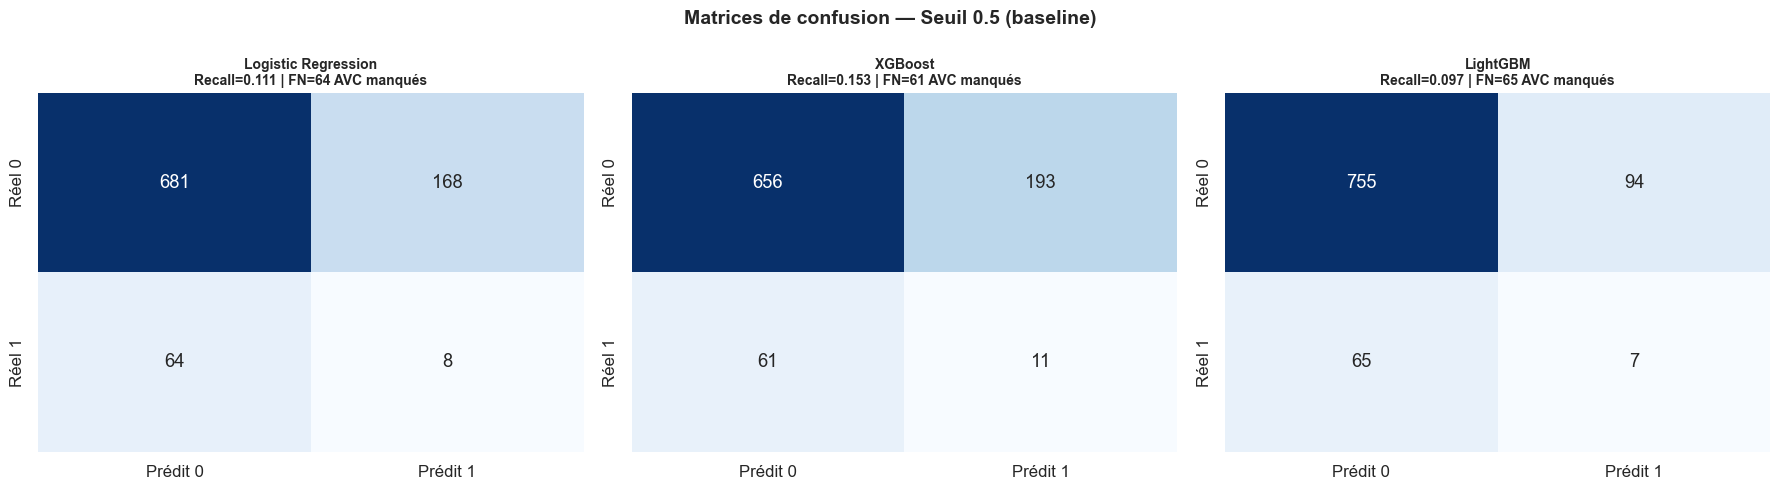

In [8]:
# Matrices de confusion — seuil 0.5
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, estimator) in zip(axes, best_estimators.items()):
    y_proba = estimator.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)
    cm      = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', cbar=False,
        xticklabels=['Prédit 0', 'Prédit 1'],
        yticklabels=['Réel 0', 'Réel 1']
    )
    recall = recall_score(y_test, y_pred)
    fn     = cm[1, 0]
    ax.set_title(f'{name}\nRecall={recall:.3f} | FN={fn} AVC manqués',
                 fontweight='bold', fontsize=10)

plt.suptitle('Matrices de confusion — Seuil 0.5 (baseline)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Seuil Dynamique — Optimisation du Recall

### Problème avec seuil 0.5
Par défaut : `proba >= 0.5 → stroke=1`. Trop restrictif → beaucoup d'AVC manqués.

### Solution : seuil optimal OOF (Out-Of-Fold)

On utilise `cross_val_predict` sur `X_train` pour obtenir des probabilités OOF —
des probabilités sur des données que le modèle n'a **jamais vues** pendant l'entraînement.

```
cross_val_predict(cv=5) :
  Fold 1 : entraîne sur 80% de X_train → prédit 20% de X_train
  Fold 2 : entraîne sur 80% de X_train → prédit 20% de X_train
  ...
  → assemblage des 5 × 20% = probabilités OOF pour 100% de X_train
```

**Avantage** : le seuil est choisi sur X_train (OOF) → **X_test reste invisible** → pas de data leakage.

### Critères de sélection du seuil optimal

```
1. Recall ≥ 0.60  → seuil clinique minimum acceptable
2. Seuil  ≥ 0.10  → évite le recall artificiel (modèle qui prédit tout stroke=1)
3. Parmi les candidats → choisir le meilleur F1 (meilleur équilibre Recall/Precision)

In [9]:
def find_optimal_threshold_cv(estimator, X_train, y_train, cv,
                               target_recall=0.60, min_threshold=0.10):
    """
    Cherche le seuil optimal via cross-validation sur X_train uniquement.
    
    Paramètres :
        target_recall  : Recall minimum clinique acceptable (0.60)
        min_threshold  : Seuil minimum pour éviter recall artificiel (0.10)
    
    Logique :
        1. Probas OOF via cross_val_predict → pas de data leakage
        2. Tester 10 seuils entre 0.05 et 0.50
        3. Filtrer : Recall >= target_recall ET seuil >= min_threshold
        4. Choisir le meilleur F1 parmi les candidats
        5. Fallback : meilleur Recall si aucun candidat valide
    """
    # Probas OOF — le modèle ne voit jamais ces données pendant l'entraînement
    y_proba_oof = cross_val_predict(
        estimator, X_train, y_train,
        cv=cv, method='predict_proba', n_jobs=-1
    )[:, 1]

    # Tester 10 seuils
    thresholds = np.arange(0.05, 0.55, 0.05)
    results = []
    for t in thresholds:
        y_pred = (y_proba_oof >= t).astype(int)
        results.append({
            'threshold': round(t, 2),
            'recall'   : recall_score(y_train, y_pred),
            'precision': precision_score(y_train, y_pred, zero_division=0),
            'f1'       : f1_score(y_train, y_pred, zero_division=0),
        })

    df_t = pd.DataFrame(results)

    # Filtrer les candidats valides
    candidates = df_t[
        (df_t['recall']    >= target_recall) &
        (df_t['threshold'] >= min_threshold)
    ]

    if candidates.empty:
        # Fallback : meilleur Recall disponible
        best = df_t.loc[df_t['recall'].idxmax()]
        print(f' Aucun candidat Recall>={target_recall} — fallback: Recall max')
    else:
        # Meilleur F1 parmi candidats
        best = candidates.loc[candidates['f1'].idxmax()]

    return float(best['threshold']), df_t


# Application sur les 3 modèles
print('=== Recherche seuil optimal OOF (sur X_train) ===\n')
print(f'{"Modèle":<25} {"Seuil optimal":>15} {"Recall OOF":>12} {"F1 OOF":>10}')
print('-' * 65)

optimal_thresholds = {}
threshold_curves   = {}

for name, estimator in best_estimators.items():
    opt_t, df_t = find_optimal_threshold_cv(
        estimator, X_train, y_train, cv,
        target_recall=0.60, min_threshold=0.10
    )
    optimal_thresholds[name] = opt_t
    threshold_curves[name]   = df_t

    # Métriques au seuil optimal OOF
    row = df_t[df_t['threshold'] == opt_t].iloc[0]
    print(f'{name:<25} {opt_t:>15.2f} {row["recall"]:>12.4f} {row["f1"]:>10.4f}')

=== Recherche seuil optimal OOF (sur X_train) ===

Modèle                      Seuil optimal   Recall OOF     F1 OOF
-----------------------------------------------------------------
Logistic Regression                  0.30       0.6310     0.1766
XGBoost                              0.35       0.7069     0.1653
LightGBM                             0.25       0.7897     0.1581


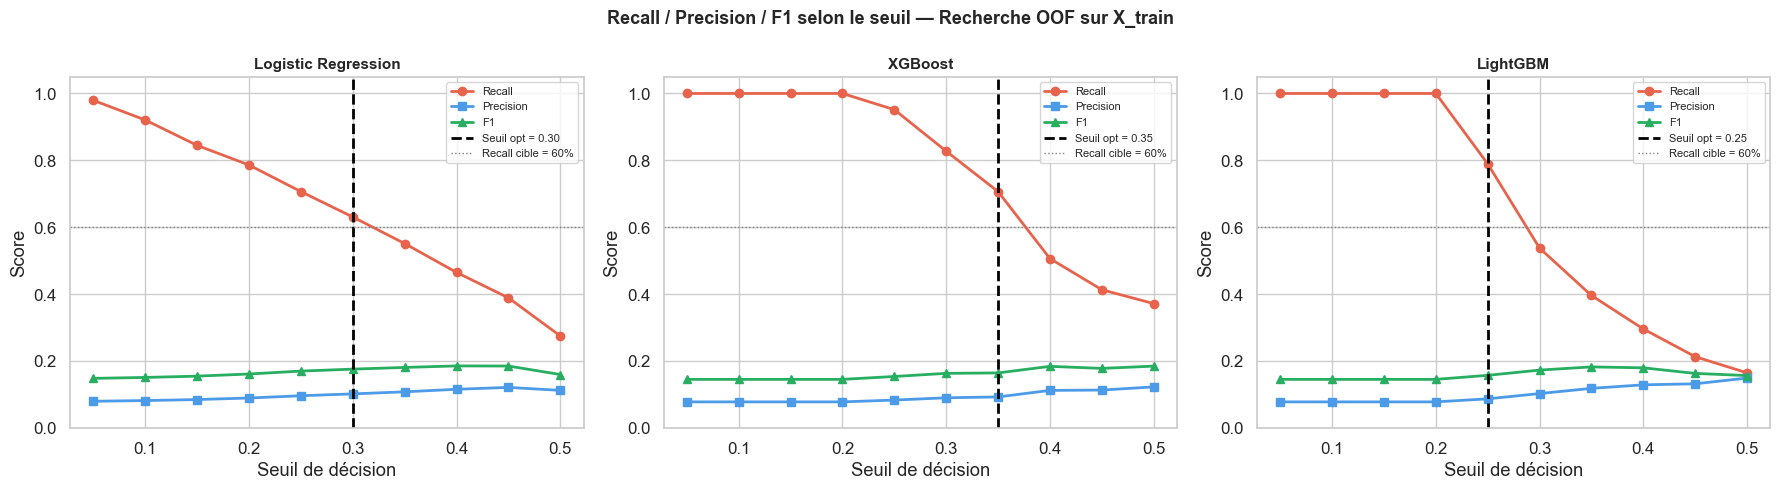

In [10]:
# Visualisation Recall / Precision / F1 selon le seuil — 3 modèles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df_t) in zip(axes, threshold_curves.items()):
    ax.plot(df_t['threshold'], df_t['recall'],
            color='#E8634C', marker='o', linewidth=2, label='Recall')
    ax.plot(df_t['threshold'], df_t['precision'],
            color='#4C9BE8', marker='s', linewidth=2, label='Precision')
    ax.plot(df_t['threshold'], df_t['f1'],
            color='#27AE60', marker='^', linewidth=2, label='F1')

    ax.axvline(optimal_thresholds[name], color='black', linestyle='--',
               linewidth=2, label=f'Seuil opt = {optimal_thresholds[name]:.2f}')
    ax.axhline(0.60, color='gray', linestyle=':', linewidth=1,
               label='Recall cible = 60%')

    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Seuil de décision')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.suptitle('Recall / Precision / F1 selon le seuil — Recherche OOF sur X_train',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Évaluation Finale — Seuil Optimal

On réévalue chaque modèle avec son seuil optimal.

In [11]:
results_optimal = []
for name, estimator in best_estimators.items():
    t = optimal_thresholds[name]
    metrics = evaluate_model(name, estimator, X_test, y_test, threshold=t)
    results_optimal.append(metrics)

df_results_optimal = pd.DataFrame(results_optimal).set_index('Modèle')

print('=== Évaluation — Seuil Optimal ===')
display(
    df_results_optimal.style
    .highlight_max(subset=['Recall', 'AUC-ROC', 'F1','PR-AUC'], color='#c6efce')
    .highlight_min(subset=['Recall'], color='#ffc7ce')
    .format('{:.4f}')
)

=== Évaluation — Seuil Optimal ===


,Seuil,Recall,Precision,F1,AUC-ROC,PR-AUC,Accuracy
Modèle,,,,,,,
Logistic Regression,0.3000,0.4583,0.0753,0.1294,0.4869,0.0730,0.5179
XGBoost,0.3500,0.6667,0.0800,0.1429,0.4971,0.0760,0.3746
LightGBM,0.2500,0.8611,0.0848,0.1544,0.5154,0.0791,0.2628


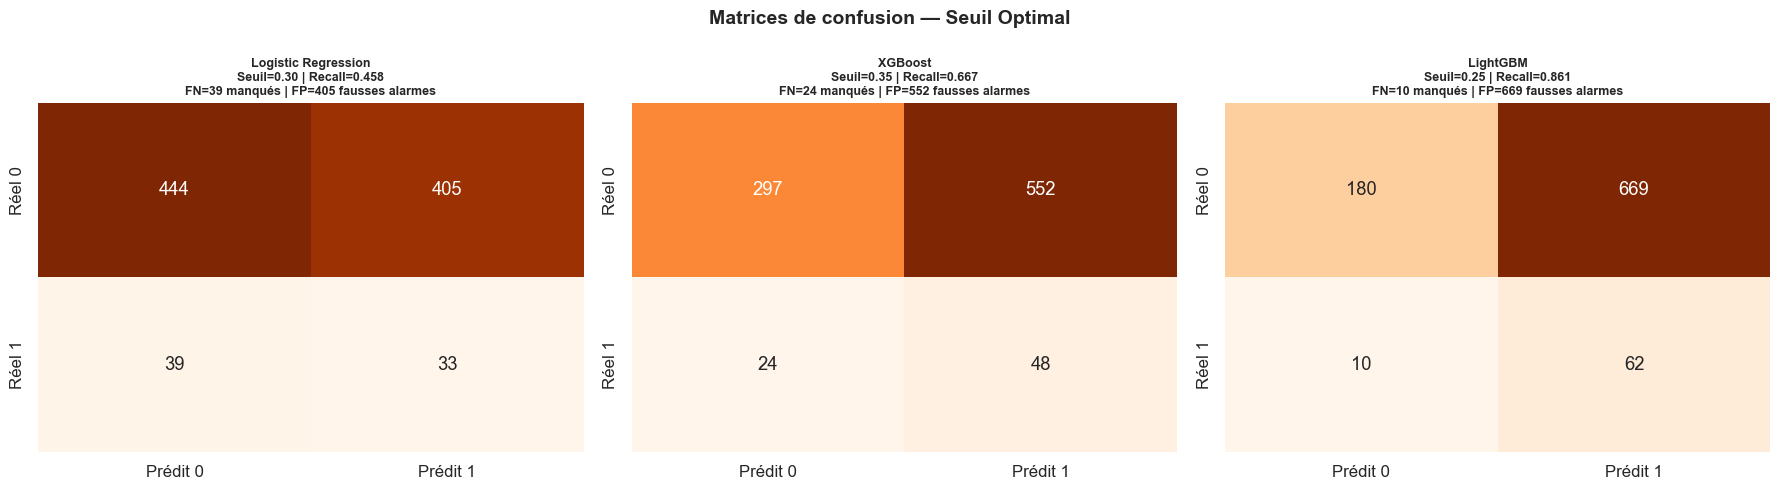

In [12]:
# Matrices de confusion — seuil optimal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, estimator) in zip(axes, best_estimators.items()):
    t       = optimal_thresholds[name]
    y_proba = estimator.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= t).astype(int)
    cm      = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Oranges', cbar=False,
        xticklabels=['Prédit 0', 'Prédit 1'],
        yticklabels=['Réel 0', 'Réel 1']
    )
    recall = recall_score(y_test, y_pred)
    fn     = cm[1, 0]
    fp     = cm[0, 1]
    ax.set_title(
        f'{name}\nSeuil={t:.2f} | Recall={recall:.3f}\nFN={fn} manqués | FP={fp} fausses alarmes',
        fontweight='bold', fontsize=9
    )

plt.suptitle('Matrices de confusion — Seuil Optimal',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

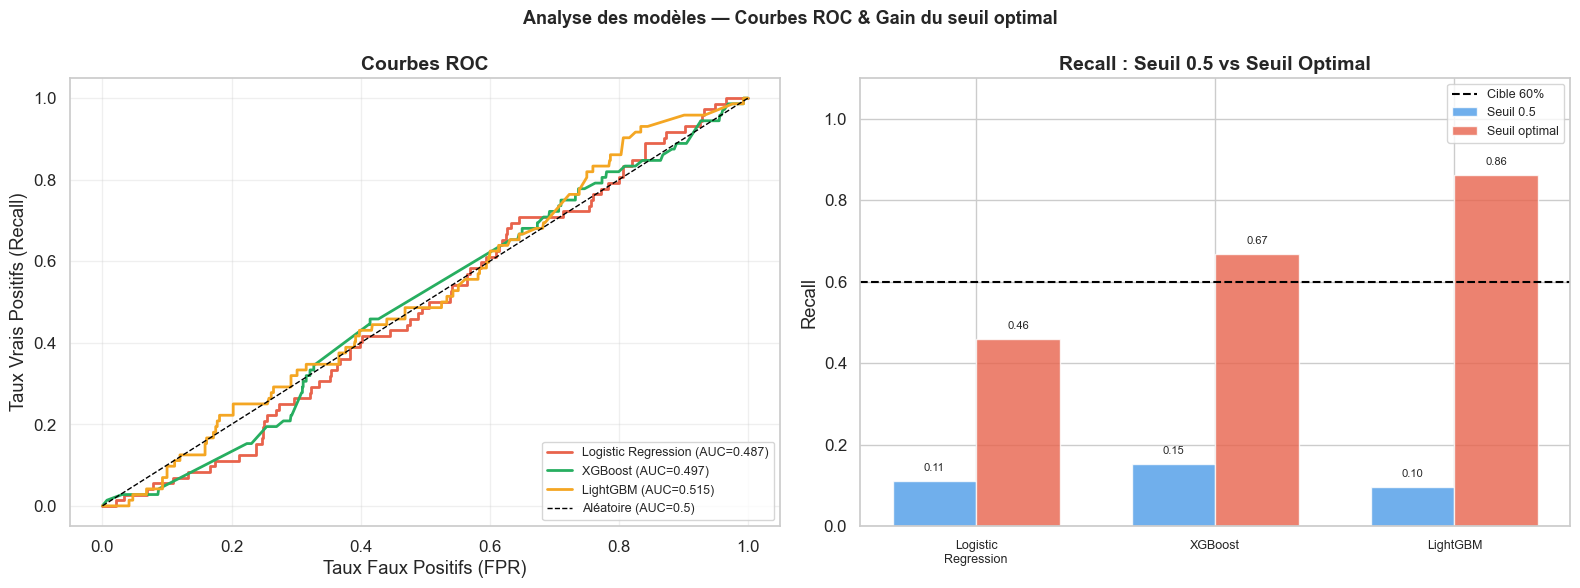

In [13]:
# Courbes ROC — 3 modèles superposées
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#E8634C', '#27AE60', '#F4A623']

# ── Courbe ROC ──────────────────────────────────────────────────────────────
ax = axes[0]
for (name, estimator), color in zip(best_estimators.items(), colors):
    y_proba = estimator.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Aléatoire (AUC=0.5)')
ax.set_xlabel('Taux Faux Positifs (FPR)')
ax.set_ylabel('Taux Vrais Positifs (Recall)')
ax.set_title('Courbes ROC', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# ── Comparaison Recall seuil 0.5 vs seuil optimal ──────────────────────────
ax = axes[1]
models_list  = list(best_estimators.keys())
recall_05    = [df_results_default.loc[m, 'Recall'] for m in models_list]
recall_opt   = [df_results_optimal.loc[m, 'Recall'] for m in models_list]

x = np.arange(len(models_list))
w = 0.35
bars1 = ax.bar(x - w/2, recall_05,  w, label='Seuil 0.5',    color='#4C9BE8', alpha=0.8)
bars2 = ax.bar(x + w/2, recall_opt, w, label='Seuil optimal', color='#E8634C', alpha=0.8)

ax.axhline(0.60, color='black', linestyle='--', linewidth=1.5, label='Cible 60%')
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in models_list], fontsize=9)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.1)
ax.set_title('Recall : Seuil 0.5 vs Seuil Optimal', fontweight='bold')
ax.legend(fontsize=9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Analyse des modèles — Courbes ROC & Gain du seuil optimal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Tableau comparatif final : seuil 0.5 vs seuil optimal
print('=== Comparaison Seuil 0.5 vs Seuil Optimal ===')
print(f'\n{"Modèle":<25} {"Recall 0.5":>10} {"Recall Opt":>12} {"Gain":>8} {"AUC":>8} {"PR-AUC":>8}')
print('-' * 75)

for name in best_estimators:
    r_05  = df_results_default.loc[name, 'Recall']
    r_opt = df_results_optimal.loc[name, 'Recall']
    auc   = df_results_optimal.loc[name, 'AUC-ROC']
    prauc = df_results_optimal.loc[name, 'PR-AUC']
    gain  = r_opt - r_05
    print(f'{name:<25} {r_05:>10.4f} {r_opt:>12.4f} {gain:>+8.4f} {auc:>8.4f} {prauc:>8.4f}')

print()

# ── Sélection du meilleur modèle ────────────────────────────────────────────
# Critère 1 : Recall >= 0.60  (seuil clinique minimum)
# Critère 2 : Seuil  >= 0.10  (évite recall artificiel)
# Tiebreaker : meilleur AUC-ROC parmi les candidats valides

candidates = df_results_optimal[
    (df_results_optimal['Recall'] >= 0.60) &
    (df_results_optimal['Seuil']  >= 0.10)
]

if candidates.empty:
    print('⚠ Aucun modèle avec Recall >= 60% et seuil >= 0.10')
    print('  → Sélection sur meilleur AUC-ROC global')
    best_model_name = df_results_optimal['AUC-ROC'].idxmax()
else:
    best_model_name = candidates['AUC-ROC'].idxmax()

print(f'✓ Meilleur modèle sélectionné : {best_model_name}')
print(f'  Critère : meilleur AUC-ROC avec Recall >= 60% et seuil >= 0.10')
print()
print(df_results_optimal.loc[best_model_name])

=== Comparaison Seuil 0.5 vs Seuil Optimal ===

Modèle                    Recall 0.5   Recall Opt     Gain      AUC   PR-AUC
---------------------------------------------------------------------------
Logistic Regression           0.1111       0.4583  +0.3472   0.4869   0.0730
XGBoost                       0.1528       0.6667  +0.5139   0.4971   0.0760
LightGBM                      0.0972       0.8611  +0.7639   0.5154   0.0791

✓ Meilleur modèle sélectionné : LightGBM
  Critère : meilleur AUC-ROC avec Recall >= 60% et seuil >= 0.10

Seuil        0.2500
Recall       0.8611
Precision    0.0848
F1           0.1544
AUC-ROC      0.5154
PR-AUC       0.0791
Accuracy     0.2628
Name: LightGBM, dtype: float64


## 8. Sauvegarde — `pipeline_final.pkl`

On sauvegarde le meilleur modèle complet (ImbPipeline entraîné)  
prêt pour le déploiement.

In [15]:
# Sauvegarde du meilleur pipeline
best_pipeline  = best_estimators[best_model_name]
best_threshold = optimal_thresholds[best_model_name]

artifact = {
    'pipeline'   : best_pipeline,
    'threshold'  : best_threshold,
    'features'   : FINAL_FEATURES,
    'model_name' : best_model_name,
}

with open(MODEL_PKL, 'wb') as f:
    pickle.dump(artifact, f)

print('=== Sauvegarde terminée ===')
print(f'  Fichier        : {MODEL_PKL}')
print(f'  Modèle         : {best_model_name}')
print(f'  Seuil optimal  : {best_threshold:.2f}')
print(f'  Features       : {len(FINAL_FEATURES)}')
print(f'  Recall final   : {df_results_optimal.loc[best_model_name, "Recall"]:.4f}')
print(f'  AUC-ROC final  : {df_results_optimal.loc[best_model_name, "AUC-ROC"]:.4f}')
print(f'  PR-AUC final   : {df_results_optimal.loc[best_model_name, "PR-AUC"]:.4f}')

# Vérification relecture
with open(MODEL_PKL, 'rb') as f:
    check = pickle.load(f)
print(f'\n✓ Vérification relecture :')
print(f'  model_name : {check["model_name"]}')
print(f'  threshold  : {check["threshold"]}')
print(f'  features   : {len(check["features"])} features')
print(f'\nModeling terminé.')

=== Sauvegarde terminée ===
  Fichier        : ./pipeline_final.pkl
  Modèle         : LightGBM
  Seuil optimal  : 0.25
  Features       : 37
  Recall final   : 0.8611
  AUC-ROC final  : 0.5154
  PR-AUC final   : 0.0791

✓ Vérification relecture :
  model_name : LightGBM
  threshold  : 0.25
  features   : 37 features

Modeling terminé.
